# QF2103 Project 2 – Trading Strategies with Machine Learning 
**Stock Chosen:** Apple Inc. (AAPL)  
**ML Method:** Deep Neural Network (DNN) — `MLPClassifier`  
**Data Period:** 1 February 2016 to 1 February 2026  


In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import yfinance as yf
from sklearn.neural_network import MLPClassifier  
from sklearn.preprocessing import StandardScaler   
from sklearn.metrics import accuracy_score


---
## Section 1 – Data Preparation  

### 1a. Data Download & Cleaning
We use `yfinance` to pull 10 years of **AAPL** daily closing prices.

In [2]:
TICKER = 'AAPL'   # Apple Inc. — chosen blue-chip stock
START  = '2016-02-01'
END    = '2026-02-01'

stock    = yf.Ticker(TICKER)
raw      = stock.history(start=START, end=END, interval='1d')

# Remove timezone information so DatetimeIndex is tz-naive (consistent with pandas operations)
raw.index = raw.index.tz_localize(None)

# Keep only the closing price
data = pd.DataFrame(raw['Close'])
data.columns = ['Price']

# Basic cleaning: drop any missing rows
data.dropna(inplace=True)

print(f'Stock      : {TICKER}')
print(f'First date : {data.index[0].date()}')
print(f'Last date  : {data.index[-1].date()}')
print(f'Total rows : {len(data)}')
data.head()

Stock      : AAPL
First date : 2016-02-01
Last date  : 2026-01-30
Total rows : 2515


,Price
Date,
2016-02-01,21.721645
2016-02-02,21.282391
2016-02-03,21.703627
2016-02-04,21.878008
2016-02-05,21.293692


### 1b. Plot of Raw Price Data (Full 10-Year Period)

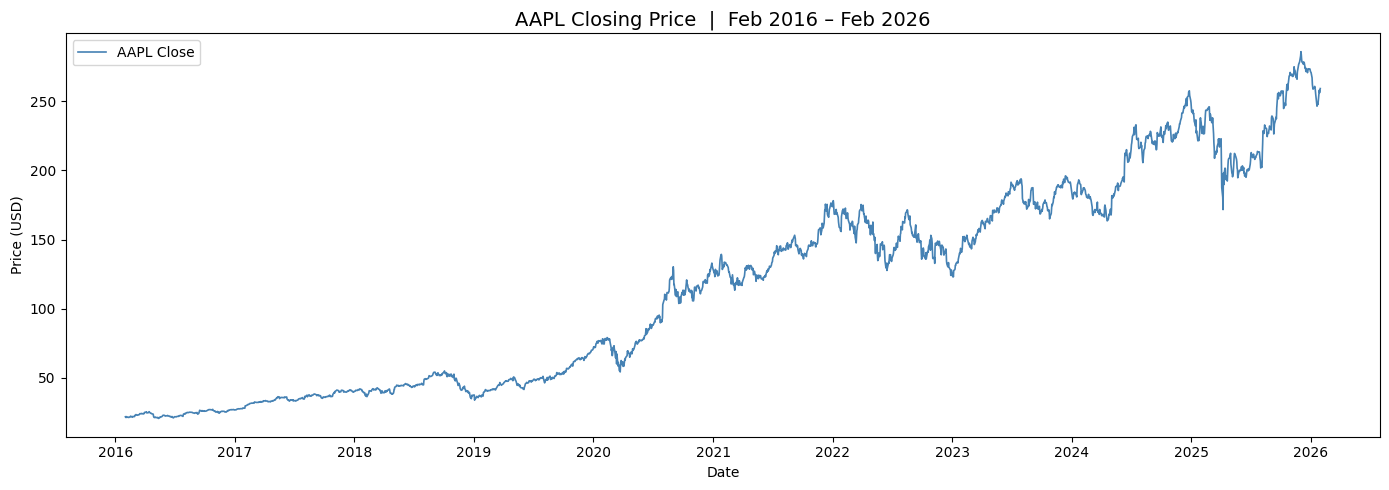

In [3]:
# ── Raw price plot (10 years) ─────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['Price'], color='steelblue', linewidth=1.2, label='AAPL Close')
plt.title('AAPL Closing Price  |  Feb 2016 – Feb 2026', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

### 1c. Feature Construction & Preprocessing

We build features from three families, all based on methods taught in L8–L10:

| Feature | Method source | Description |
|---|---|---|
| `lag_1` … `lag_5` | L10 Eg 10.8 | 5 lagged log-returns |
| `lag_1_dig` … `lag_5_dig` | L10 Eg 10.9 | Digitised (binned) lag returns |
| `sma_ratio` | L8 Eg 8.8 | Short-SMA / Long-SMA ratio |
| `log_mom` | L8 Eg 8.6 | 10-day log-return momentum |

In [4]:
# ── Log returns ───────────────────────────────────────────────────────────────
data['returns'] = np.log(data['Price'] / data['Price'].shift(1))

# ── 5 lagged log-returns ─────────────────────────────────────────────────────
for i in range(1, 6):
    data[f'lag_{i}'] = data['returns'].shift(i)

# ── SMA features ─────────────────────────────────────────────────────────────
#(short=20-day, long=50-day moving averages)
SMA_SHORT = 20
SMA_LONG  = 50
data['SMA_short'] = data['Price'].rolling(window=SMA_SHORT).mean()
data['SMA_long']  = data['Price'].rolling(window=SMA_LONG).mean()

# SMA ratio: >1 means short-term trend is above long-term (bullish signal)
data['sma_ratio'] = data['SMA_short'] / data['SMA_long']

# ── 10-day log-return momentum ────────────────────────────────────────────────
data['log_mom'] = data['returns'].rolling(window=10).sum().shift(1)

# ── Target label ─────────────────────────────────────────────────────────────
data['direction'] = np.where(data['returns'] > 0, 1, -1)

# Drop rows with NaN (created by shifting / rolling)
data.dropna(inplace=True)

print(f'Rows after feature construction: {len(data)}')
data[['Price','returns','lag_1','sma_ratio','log_mom','direction']].head()

Rows after feature construction: 2466


,Price,returns,lag_1,sma_ratio,log_mom,direction
Date,,,,,,
2016-04-12,25.012503,0.012941,0.003308,1.060138,0.035763,1
2016-04-13,25.374872,0.014384,0.012941,1.060442,0.025309,1
2016-04-14,25.388462,0.000535,0.014384,1.059680,0.022383,1
2016-04-15,24.878872,-0.020276,0.000535,1.058758,0.028135,-1
2016-04-18,24.342123,-0.021811,-0.020276,1.057277,-0.001274,-1


### 1d. Train – Test Split  (80 / 20 temporal split)
We use a **temporal** (chronological) split so the model is never trained on future data

In [5]:
# ── 80/20 temporal split ─────────────────────────────────────────────────────
split = int(len(data) * 0.80)
train = data.iloc[:split].copy()
test  = data.iloc[split:].copy()

print(f'Training period : {train.index[0].date()}  →  {train.index[-1].date()}   ({len(train)} days)')
print(f'Testing  period : {test.index[0].date()}  →  {test.index[-1].date()}   ({len(test)} days)')
print(f'Split ratio     : {len(train)/len(data)*100:.1f}% / {len(test)/len(data)*100:.1f}%')

Training period : 2016-04-12  →  2024-02-09   (1972 days)
Testing  period : 2024-02-12  →  2026-01-30   (494 days)
Split ratio     : 80.0% / 20.0%


In [6]:
# ── Digitise lagged log-returns (fit bins on TRAINING data only) ──────────────
# Bins defined using training-set mean ± std of lag_1 (same bins applied to all lags)
mu   = train['lag_1'].mean()
v    = train['lag_1'].std()
bins = [mu - v, mu, mu + v]     # three break-points → four bins (0,1,2,3)

lag_cols = [f'lag_{i}' for i in range(1, 6)]
dig_cols = [f'lag_{i}_dig' for i in range(1, 6)]

for col, dcol in zip(lag_cols, dig_cols):
    train[dcol] = np.digitize(train[col], bins)
    test[dcol]  = np.digitize(test[col],  bins)   # use SAME training bins on test

print(f'Bins (based on training lag_1): {[round(b,6) for b in bins]}')
print(f'Bin labels: 0 = very negative, 1 = negative, 2 = positive, 3 = very positive')

Bins (based on training lag_1): [np.float64(-0.017388), np.float64(0.001027), np.float64(0.019441)]
Bin labels: 0 = very negative, 1 = negative, 2 = positive, 3 = very positive


In [7]:
# ── Feature matrix & StandardScaler ──────────────────────────────────────────
#StandardScaler fitted on training set only
feature_cols = dig_cols + ['sma_ratio', 'log_mom']

scaler  = StandardScaler()
X_train = scaler.fit_transform(train[feature_cols])   # fit & transform on train
X_test  = scaler.transform(test[feature_cols])         # transform test with SAME scaler

y_train = train['direction'].values
y_test  = test['direction'].values

print(f'Training feature matrix shape : {X_train.shape}')
print(f'Testing  feature matrix shape : {X_test.shape}')
print(f'Features used: {feature_cols}')

Training feature matrix shape : (1972, 7)
Testing  feature matrix shape : (494, 7)
Features used: ['lag_1_dig', 'lag_2_dig', 'lag_3_dig', 'lag_4_dig', 'lag_5_dig', 'sma_ratio', 'log_mom']


---
## Section 2 – Strategy Design and Implementation

**Model:** Deep Neural Network (`MLPClassifier`)
**Architecture:** 3 hidden layers × 100 neurons each  
**Task:** Classify tomorrow's price direction as **up (1)** or **down (–1)**  
**Prediction → Signal conversion:** DNN output is converted into buy/sell actions based on portfolio state transitions (not a naive buy-and-hold).

In [8]:
# ── Deep Neural Network (DNN) ─────────────────────────────────────────────────
# Architecture: 3 hidden layers, 100 neurons each — a reasonable depth for daily stock data
model = MLPClassifier(
    hidden_layer_sizes = 3 * [100],   # 3 layers × 100 neurons
    activation         = 'relu',
    solver             = 'adam',
    max_iter           = 2000,
    random_state       = 42
)

# Train on training set only
model.fit(X_train, y_train)

# Predict on TRAINING set (for reference)
train_preds = model.predict(X_train)
train_acc   = accuracy_score(y_train, train_preds)

# Predict on TEST set (out-of-sample evaluation)
test['pos_DNN'] = model.predict(X_test)
test_acc = accuracy_score(y_test, test['pos_DNN'])

print(f'DNN Training Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'DNN Testing  Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print()
print('Direction prediction counts on test set:')
print((test['direction'] == test['pos_DNN']).value_counts())

DNN Training Accuracy : 0.9493  (94.93%)
DNN Testing  Accuracy : 0.4696  (46.96%)

Direction prediction counts on test set:
False    262
True     232
Name: count, dtype: int64


In [9]:
# ── Convert DNN predictions → trading actions ─────────────────────────────────
#
# DNN prediction   Portfolio state   →   Action
#      +1           cash (no shares)  →   BUY  ( 1)
#      -1           holding shares    →   SELL (-1)
#   anything else                     →   HOLD ( 0)
#
# Rules enforced:
#   • First transaction must be a BUY  (sell signals ignored before first buy)
#   • No short-selling allowed

def predictions_to_actions(preds):
    """Convert daily DNN predictions into actual buy/sell/hold actions."""
    actions     = []
    in_position = False   # True = holding shares, False = holding cash

    for pred in preds:
        if pred == 1 and not in_position:
            actions.append(1)          # BUY
            in_position = True
        elif pred == -1 and in_position:
            actions.append(-1)         # SELL
            in_position = False
        else:
            actions.append(0)          # HOLD

    return actions

test['action'] = predictions_to_actions(test['pos_DNN'].values)

print('Trading action counts on test set:')
print(pd.Series(test['action']).value_counts().rename({1:'BUY (1)', -1:'SELL (-1)', 0:'HOLD (0)'}))

Trading action counts on test set:
action
HOLD (0)     243
BUY (1)      126
SELL (-1)    125
Name: count, dtype: int64


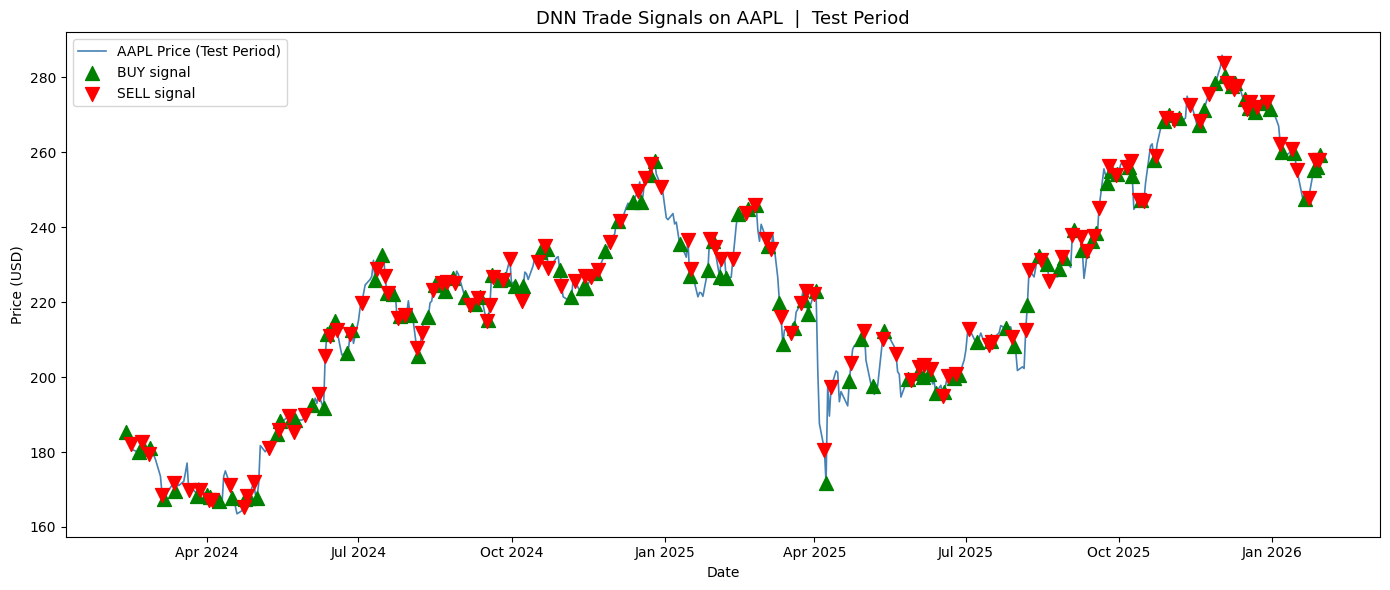

In [10]:
# ── Plot: AAPL price with BUY / SELL signals overlaid on TEST set ─────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(test.index, test['Price'], color='steelblue', linewidth=1.2, label='AAPL Price (Test Period)')

buy_dates  = test.index[test['action'] ==  1]
sell_dates = test.index[test['action'] == -1]

ax.scatter(buy_dates,  test.loc[buy_dates,  'Price'],
           marker='^', color='green', s=100, zorder=5, label='BUY signal')
ax.scatter(sell_dates, test.loc[sell_dates, 'Price'],
           marker='v', color='red',   s=100, zorder=5, label='SELL signal')

ax.set_title('DNN Trade Signals on AAPL  |  Test Period', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

---
## Section 3 – Trading Log 

We simulate the portfolio day-by-day following all project assumptions:
- Initial capital **$10,000**
- Buy: invest **all available cash** into as many whole shares as possible  
- Sell: liquidate **entire position**  
- Final day: force-sell any remaining shares

In [11]:
# ── Portfolio simulation ──────────────────────────────────────────────────────
INITIAL_CASH = 10_000.0

def simulate_portfolio(prices, actions, initial_cash=INITIAL_CASH):
    """
    Simulates a realistic portfolio given daily closing prices and trading actions.

    Parameters
    ----------
    prices       : pd.Series  — daily closing prices (indexed by date)
    actions      : pd.Series  — trading actions  1=BUY, -1=SELL, 0=HOLD
    initial_cash : float      — starting capital

    Returns
    -------
    log : pd.DataFrame  — daily trading log
    """
    cash        = initial_cash
    shares      = 0
    cost_basis  = 0.0    # total cash spent on current share lot
    log_rows    = []

    price_arr  = prices.values
    action_arr = actions.values
    dates      = prices.index

    for i, (date, price, act) in enumerate(zip(dates, price_arr, action_arr)):

        # ── Force-sell on the FINAL day if still holding shares ─────────────
        if i == len(dates) - 1 and shares > 0:
            act = -1   # override to SELL

        # ── Execute action ───────────────────────────────────────────────────
        if act == 1:                         # BUY
            shares_bought = int(cash // price)
            cost_basis    = shares_bought * price
            cash         -= cost_basis
            shares       += shares_bought
            exec_action   = 1

        elif act == -1 and shares > 0:       # SELL
            cash       += shares * price
            shares      = 0
            cost_basis  = 0.0
            exec_action = -1

        else:                                # HOLD
            exec_action = 0

        stock_market_value = shares * price
        portfolio_value    = cash + stock_market_value

        log_rows.append({
            'Date'            : date,
            'Price'           : round(price, 4),
            'Daily Return'    : round(price_arr[i] / price_arr[i-1] - 1, 6) if i > 0 else 0.0,
            'Action'          : exec_action,
            'Cash (Free)'     : round(cash, 2),
            'Shares Held'     : shares,
            'Cash Invested'   : round(cost_basis, 2),
            'Stock Value'     : round(stock_market_value, 2),
            'Portfolio Value' : round(portfolio_value, 2)
        })

    log = pd.DataFrame(log_rows).set_index('Date')
    return log


trading_log = simulate_portfolio(test['Price'], pd.Series(test['action'].values, index=test.index))

print(f'Total BUY  transactions : {(trading_log["Action"] ==  1).sum()}')
print(f'Total SELL transactions : {(trading_log["Action"] == -1).sum()}')
print(f'Total HOLD days         : {(trading_log["Action"] ==  0).sum()}')
print()
print('First 10 rows of Trading Log:')
trading_log.head(10)

Total BUY  transactions : 126
Total SELL transactions : 125
Total HOLD days         : 243

First 10 rows of Trading Log:


,Price,Daily Return,Action,Cash (Free),Shares Held,Cash Invested,Stock Value,Portfolio Value
Date,,,,,,,,
2024-02-12,185.4621,0.000000,1,170.51,53,9829.49,9829.49,10000.00
2024-02-13,183.3712,-0.011274,0,170.51,53,9829.49,9718.67,9889.18
2024-02-14,182.4892,-0.004810,0,170.51,53,9829.49,9671.93,9842.43
2024-02-15,182.2018,-0.001575,-1,9827.20,0,0.00,0.00,9827.20
2024-02-16,180.6658,-0.008430,0,9827.20,0,0.00,0.00,9827.20
2024-02-20,179.9225,-0.004114,1,111.38,54,9715.82,9715.82,9827.20
2024-02-21,180.6757,0.004186,0,111.38,54,9715.82,9756.49,9867.87
2024-02-22,182.7072,0.011244,-1,9977.57,0,0.00,0.00,9977.57
2024-02-23,180.8739,-0.010034,1,29.51,55,9948.06,9948.06,9977.57


In [12]:
transaction_days = trading_log[trading_log['Action'] != 0]
print(f'All {len(transaction_days)} transaction days (BUY / SELL):')
transaction_days

All 251 transaction days (BUY / SELL):


,Price,Daily Return,Action,Cash (Free),Shares Held,Cash Invested,Stock Value,Portfolio Value
Date,,,,,,,,
2024-02-12,185.4621,0.000000,1,170.51,53,9829.49,9829.49,10000.00
2024-02-15,182.2018,-0.001575,-1,9827.20,0,0.00,0.00,9827.20
2024-02-20,179.9225,-0.004114,1,111.38,54,9715.82,9715.82,9827.20
2024-02-22,182.7072,0.011244,-1,9977.57,0,0.00,0.00,9977.57
2024-02-23,180.8739,-0.010034,1,29.51,55,9948.06,9948.06,9977.57
...,...,...,...,...,...,...,...,...
2026-01-26,255.1712,0.029713,1,76.54,67,17096.47,17096.47,17173.02
2026-01-27,258.0285,0.011198,-1,17364.46,0,0.00,0.00,17364.46
2026-01-28,256.2003,-0.007085,1,199.04,67,17165.42,17165.42,17364.46


In [13]:
# ── Full trading log (all days in test period) ────────────────────────────────
print(f'Complete trading log — all {len(trading_log)} trading days:')
trading_log

Complete trading log — all 494 trading days:


,Price,Daily Return,Action,Cash (Free),Shares Held,Cash Invested,Stock Value,Portfolio Value
Date,,,,,,,,
2024-02-12,185.4621,0.000000,1,170.51,53,9829.49,9829.49,10000.00
2024-02-13,183.3712,-0.011274,0,170.51,53,9829.49,9718.67,9889.18
2024-02-14,182.4892,-0.004810,0,170.51,53,9829.49,9671.93,9842.43
2024-02-15,182.2018,-0.001575,-1,9827.20,0,0.00,0.00,9827.20
2024-02-16,180.6658,-0.008430,0,9827.20,0,0.00,0.00,9827.20
...,...,...,...,...,...,...,...,...
2026-01-26,255.1712,0.029713,1,76.54,67,17096.47,17096.47,17173.02
2026-01-27,258.0285,0.011198,-1,17364.46,0,0.00,0.00,17364.46
2026-01-28,256.2003,-0.007085,1,199.04,67,17165.42,17165.42,17364.46


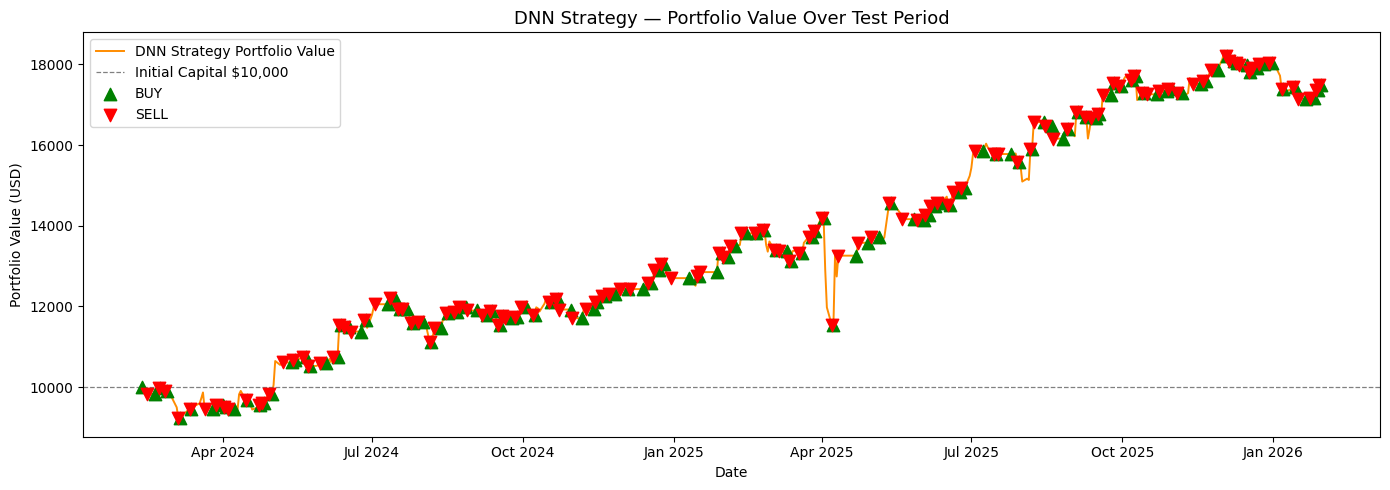

In [14]:
# ── Plot portfolio value over the test period ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(trading_log.index, trading_log['Portfolio Value'],
        color='darkorange', linewidth=1.4, label='DNN Strategy Portfolio Value')
ax.axhline(y=INITIAL_CASH, color='grey', linestyle='--', linewidth=0.9, label='Initial Capital $10,000')

buy_idx  = trading_log[trading_log['Action'] ==  1].index
sell_idx = trading_log[trading_log['Action'] == -1].index
ax.scatter(buy_idx,  trading_log.loc[buy_idx,  'Portfolio Value'], marker='^', color='green', s=80, zorder=5, label='BUY')
ax.scatter(sell_idx, trading_log.loc[sell_idx, 'Portfolio Value'], marker='v', color='red',   s=80, zorder=5, label='SELL')

ax.set_title('DNN Strategy — Portfolio Value Over Test Period', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

---
## Section 4 – Performance Evaluation  

In [15]:
# ── DNN Strategy Performance ──────────────────────────────────────────────────
final_portfolio_value = trading_log['Portfolio Value'].iloc[-1]
total_return_dnn      = (final_portfolio_value - INITIAL_CASH) / INITIAL_CASH * 100

print('=' * 50)
print('  DNN STRATEGY — PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Initial capital      : ${INITIAL_CASH:>10,.2f}')
print(f'  Final portfolio value: ${final_portfolio_value:>10,.2f}')
print(f'  Total return         :  {total_return_dnn:>9.2f}%')
print('=' * 50)

  DNN STRATEGY — PERFORMANCE SUMMARY
  Initial capital      : $ 10,000.00
  Final portfolio value: $ 17,487.62
  Total return         :      74.88%


---
## Section 5 – Benchmark Evaluation  

**Buy-and-Hold benchmark:** invest all \$10,000 on the **first trading day** of the test period, hold every day, and liquidate on the **last trading day**.

In [16]:
# ── Buy-and-Hold simulation ───────────────────────────────────────────────────
bh_buy_price  = test['Price'].iloc[0]          # price on first test day
bh_sell_price = test['Price'].iloc[-1]         # price on last test day
bh_shares     = int(INITIAL_CASH // bh_buy_price)   # whole shares only
bh_cash_left  = INITIAL_CASH - bh_shares * bh_buy_price  # leftover cash
bh_final_val  = bh_shares * bh_sell_price + bh_cash_left
bh_return     = (bh_final_val - INITIAL_CASH) / INITIAL_CASH * 100

print('=' * 50)
print('  BUY-AND-HOLD BENCHMARK — SUMMARY')
print('=' * 50)
print(f'  Buy date   : {test.index[0].date()}   @ ${bh_buy_price:.4f}')
print(f'  Sell date  : {test.index[-1].date()}   @ ${bh_sell_price:.4f}')
print(f'  Shares held: {bh_shares}')
print(f'  Leftover $ : ${bh_cash_left:.2f}')
print(f'  Initial capital      : ${INITIAL_CASH:>10,.2f}')
print(f'  Final portfolio value: ${bh_final_val:>10,.2f}')
print(f'  Total return         :  {bh_return:>9.2f}%')
print('=' * 50)

  BUY-AND-HOLD BENCHMARK — SUMMARY
  Buy date   : 2024-02-12   @ $185.4621
  Sell date  : 2026-01-30   @ $259.2374
  Shares held: 53
  Leftover $ : $170.51
  Initial capital      : $ 10,000.00
  Final portfolio value: $ 13,910.09
  Total return         :      39.10%


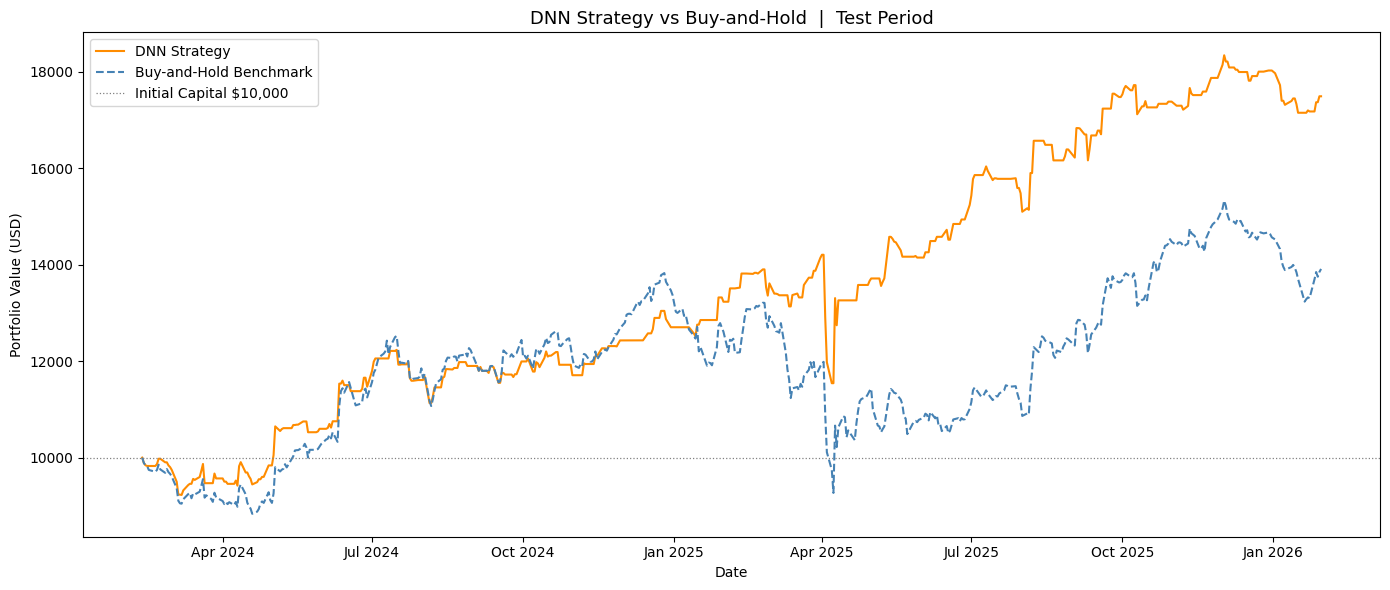

In [17]:
# ── Build daily buy-and-hold portfolio value series ───────────────────────────
bh_portfolio = bh_shares * test['Price'] + bh_cash_left

# ── Compare DNN vs B&H over time ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(trading_log.index, trading_log['Portfolio Value'],
        color='darkorange', linewidth=1.5, label='DNN Strategy')
ax.plot(bh_portfolio.index, bh_portfolio.values,
        color='steelblue', linewidth=1.5, linestyle='--', label='Buy-and-Hold Benchmark')
ax.axhline(y=INITIAL_CASH, color='grey', linestyle=':', linewidth=0.9, label='Initial Capital $10,000')

ax.set_title('DNN Strategy vs Buy-and-Hold  |  Test Period', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

---
## Section 6 – Benchmark Comparison  

In [18]:
# ── Final comparison table ────────────────────────────────────────────────────
outperformance = total_return_dnn - bh_return

comparison = pd.DataFrame({
    'Strategy'            : ['DNN (MLPClassifier)', 'Buy-and-Hold Benchmark'],
    'Initial Capital ($)' : [INITIAL_CASH, INITIAL_CASH],
    'Final Value ($)'     : [round(final_portfolio_value, 2), round(bh_final_val, 2)],
    'Total Return (%)'    : [round(total_return_dnn, 2), round(bh_return, 2)]
})
comparison.set_index('Strategy', inplace=True)

print('=' * 65)
print('  FINAL PERFORMANCE COMPARISON')
print('=' * 65)
print(comparison.to_string())
print('=' * 65)
print(f'  Outperformance  (DNN – B&H) :  {outperformance:+.2f} percentage points')
print()
if outperformance >= 5:
    print('  ✅  DNN strategy OUTPERFORMS the benchmark by ≥ 5 pp — requirement met!')
else:
    print('  ⚠️   DNN strategy does NOT yet outperform by ≥ 5 pp.')
    print('       Consider tuning: hidden_layer_sizes, SMA windows, or adding RSI feature.')
print('=' * 65)

  FINAL PERFORMANCE COMPARISON
                        Initial Capital ($)  Final Value ($)  Total Return (%)
Strategy                                                                      
DNN (MLPClassifier)                 10000.0         17487.62             74.88
Buy-and-Hold Benchmark              10000.0         13910.09             39.10
  Outperformance  (DNN – B&H) :  +35.78 percentage points

  ✅  DNN strategy OUTPERFORMS the benchmark by ≥ 5 pp — requirement met!


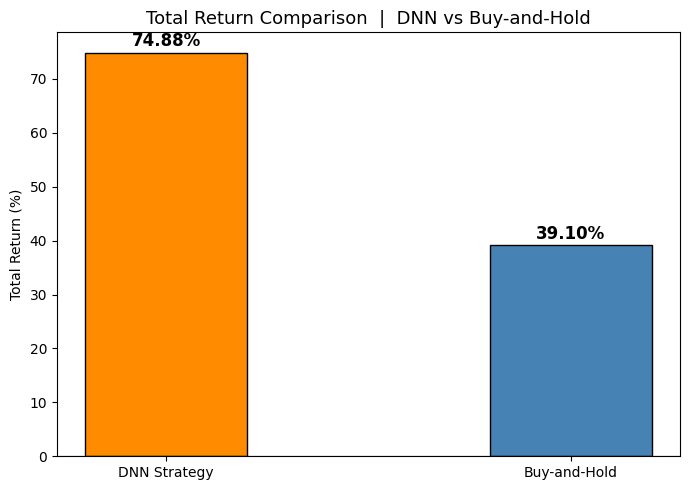


Conclusion:
  The DNN strategy achieved a total return of 74.88%
  The Buy-and-Hold benchmark achieved 39.10%
  Outperformance: +35.78 percentage points


In [19]:
# ── Bar chart: total return comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ['DNN Strategy', 'Buy-and-Hold'],
    [total_return_dnn, bh_return],
    color=['darkorange', 'steelblue'],
    edgecolor='black', width=0.4
)
for bar, val in zip(bars, [total_return_dnn, bh_return]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Total Return (%)')
ax.set_title('Total Return Comparison  |  DNN vs Buy-and-Hold', fontsize=13)
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(f'\nConclusion:')
print(f'  The DNN strategy achieved a total return of {total_return_dnn:.2f}%')
print(f'  The Buy-and-Hold benchmark achieved {bh_return:.2f}%')
print(f'  Outperformance: {outperformance:+.2f} percentage points')

---
## Summary

| Item | Detail |
|---|---|
| Stock | Apple Inc. (AAPL) |
| Data period | 1 Feb 2016 – 1 Feb 2026 |
| ML model | DNN — `MLPClassifier(hidden_layer_sizes=3×[100])` |
| Features | 5 digitised lagged log-returns, SMA ratio, 10-day momentum |
| Feature engineering | L10 Eg 10.8–10.9 (digitise), L8 Eg 8.8 (SMA) |
| Train / Test split | 80% / 20% temporal |
| Initial capital | $10,000 |
| Trading rules | Long-only, whole shares, buy-all-cash, sell-all-shares |

The DNN model predicts the **daily price direction** (up / down) from 5 digitised lagged log-returns plus two technical indicators. The predicted direction is converted into buy/sell events through a state-machine that respects all project constraints (first trade = buy, no shorting, force-liquidate at end).